In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLPClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.fc_layers = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

In [ ]:

IMG_SIZE = 224
INPUT_SIZE = IMG_SIZE * IMG_SIZE * 3
NUM_CLASSES = 15
data_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])



In [ ]:
import os
data_path = "Vegetables" if os.path.isdir("Vegetables") else "/content/drive/MyDrive/Vegetables"
train_set = datasets.ImageFolder(f"{data_path}/train", transform=data_transforms)
test_set = datasets.ImageFolder(f"{data_path}/test", transform=data_transforms)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLPClassifier(INPUT_SIZE, NUM_CLASSES).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
import matplotlib.pyplot as plt

epochs = 25

loss_list = []
acc_list = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # calculamos el promedio de pérdida y la accuracy de la época
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    # guardamos los valores para graficar
    loss_list.append(avg_loss)
    acc_list.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")


Epoch 1/25, Loss: 7.9486, Accuracy: 19.30%
Epoch 2/25, Loss: 2.6406, Accuracy: 27.63%
Epoch 3/25, Loss: 2.0986, Accuracy: 34.67%
Epoch 4/25, Loss: 1.8613, Accuracy: 40.67%
Epoch 5/25, Loss: 1.7564, Accuracy: 43.73%
Epoch 6/25, Loss: 1.6931, Accuracy: 46.73%
Epoch 7/25, Loss: 1.5822, Accuracy: 50.27%
Epoch 8/25, Loss: 1.4887, Accuracy: 52.77%
Epoch 9/25, Loss: 1.3484, Accuracy: 56.40%
Epoch 10/25, Loss: 1.4013, Accuracy: 56.50%
Epoch 11/25, Loss: 1.3192, Accuracy: 58.70%
Epoch 12/25, Loss: 1.3366, Accuracy: 59.67%
Epoch 13/25, Loss: 1.3244, Accuracy: 60.27%
Epoch 14/25, Loss: 1.2917, Accuracy: 62.80%
Epoch 15/25, Loss: 1.1931, Accuracy: 63.57%
Epoch 16/25, Loss: 1.2329, Accuracy: 63.13%
Epoch 17/25, Loss: 1.1974, Accuracy: 64.87%
Epoch 18/25, Loss: 1.1112, Accuracy: 67.30%
Epoch 19/25, Loss: 1.1773, Accuracy: 66.40%
Epoch 20/25, Loss: 1.1829, Accuracy: 66.37%
Epoch 21/25, Loss: 1.1237, Accuracy: 68.63%
Epoch 22/25, Loss: 1.1448, Accuracy: 67.40%
Epoch 23/25, Loss: 1.0998, Accuracy: 68.8

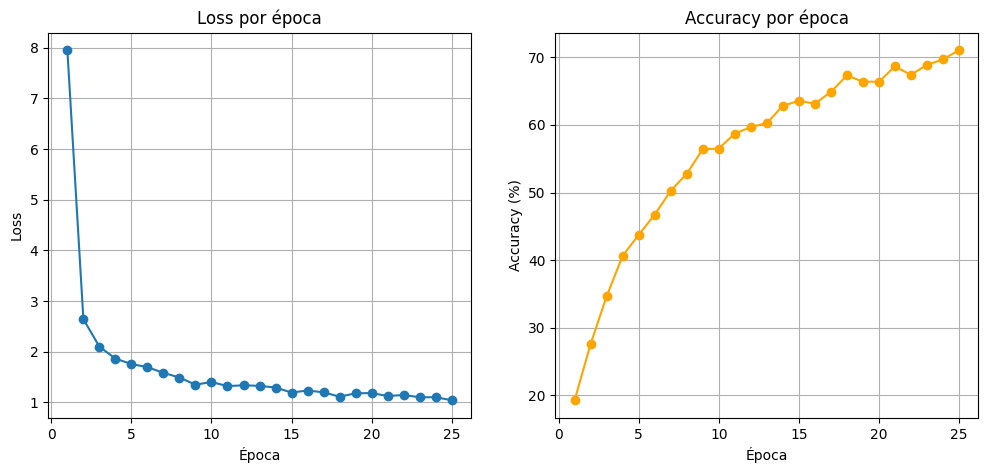

In [ ]:
plt.figure(figsize=(12,5))

# Pérdida
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), loss_list, marker='o')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), acc_list, marker='o', color='orange')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.show()

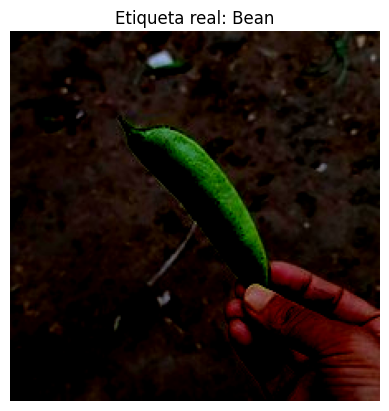

tensor([[ 4.2221,  1.1999, -0.7122,  0.9619, -2.5023, -1.2825, -0.6190, -2.2297,
         -1.3533,  2.0103,  0.8574, -1.5946, -0.9246, -4.9310, -2.2483]])
tensor([0])
Predicción del modelo: Bean


In [ ]:
import matplotlib.pyplot as plt
i = 9

images, labels = next(iter(test_loader))
image = images[i].to(device).unsqueeze(0)
label = labels[i]


class_names = test_set.classes


plt.imshow(images[i].squeeze().permute(1, 2, 0))
plt.title(f'Etiqueta real: {class_names[label]}')
plt.axis('off')
plt.show()


model.eval()

with torch.no_grad():
    output = model(image)
    print(output)
    _, predicted = torch.max(output, 1)
    print(predicted)
    print(f'Predicción del modelo: {class_names[predicted.item()]}')

In [ ]:
torch.save(model.state_dict(), 'modelo_vegetales.pth')